# Plant Disease Detection + LLM Explanation

Two-stage pipeline:
1. EfficientNetB3 detects which diseases are present
2. Groq LLM explains the diseases and gives actionable advice

**Run every cell top to bottom.**

## Cell 1 — Install + imports

In [1]:
!pip install timm groq -q

import torch
import torch.nn as nn
import timm
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from google.colab import files
from groq import Groq

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

PP_LABELS = ['complex', 'frog_eye_leaf_spot', 'healthy', 'powdery_mildew', 'rust', 'scab']

val_test_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class PlantDiseaseModel(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.backbone = timm.create_model('efficientnet_b3', pretrained=False, num_classes=0)
        in_features = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        x = self.backbone(x)
        return self.classifier(x)

print('Ready.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 5.0 MB/s eta 0:00:00
Device: cuda
Ready.


## Cell 2 — Load model

### Option A — from Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

MODEL_PATH = '/content/drive/MyDrive/plant_disease_checkpoints/phase2_final.pth'

model = PlantDiseaseModel().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print(f'Model loaded from Drive.')

Mounted at /content/drive
Model loaded from Drive.


### Option B — upload locally

In [3]:
# uploaded = files.upload()  # upload phase2_final.pth
# model_filename = list(uploaded.keys())[0]

# model = PlantDiseaseModel().to(device)
# model.load_state_dict(torch.load(model_filename, map_location=device))
# model.eval()
# print(f'Model loaded from upload.')

## Cell 3 — Set up Groq client

In [ ]:

client = Groq(api_key=GROQ_API_KEY)

DISEASE_KNOWLEDGE = {
    'scab': 'Apple Scab (Venturia inaequalis) — a fungal disease causing dark, scaly lesions on leaves and fruit.',
    'rust': 'Apple Rust (Gymnosporangium juniperi-virginianae) — a fungal disease causing bright orange-yellow spots on leaves.',
    'frog_eye_leaf_spot': 'Frog Eye Leaf Spot (Botryosphaeria obtusa) — a fungal disease causing circular brown spots with purple borders resembling a frog\'s eye.',
    'powdery_mildew': 'Powdery Mildew (Podosphaera leucotricha) — a fungal disease causing white powdery coating on leaves and shoots.',
    'complex': 'Complex infection — multiple overlapping disease symptoms that indicate a severely stressed plant with more than one active infection.',
    'healthy': 'No disease detected — the leaf appears healthy with no visible symptoms.'
}

SYSTEM_PROMPT = """You are a knowledgeable and friendly plant pathologist helping farmers understand and deal with apple leaf diseases.

Talk like a real expert having a conversation — clear, confident, and practical. No fluff, no filler, no repeating yourself.

Structure every response like this, using these exact headers in bold:

**What's going on**
One or two sentences explaining the diagnosis and what it means for the plant right now.

**How it spreads**
How the disease moves and what conditions make it worse. Keep it to 2-3 sentences.

**Act now**
A short numbered list of immediate physical actions — removing leaves, improving airflow, disinfecting tools etc.

**Treatment**
Two to three specific options — name the actual fungicides or organic products. One sentence each.

**If ignored**
One or two sentences on what happens if untreated. Be honest, not dramatic.

Rules:
- Use the confidence score when mentioning the diagnosis
- Name specific products and fungicides, not just categories
- Maximum 200 words total
- End after the last section, no closing remarks"""
def get_disease_explanation(detected_diseases, confidence_scores):

    if not detected_diseases:
        user_prompt = """The plant disease detection system analyzed an apple leaf and found NO diseases.
The leaf appears completely healthy.

Please provide:
- Confirmation of what a healthy apple leaf looks like
- Preventive care tips to keep it healthy
- Early warning signs the farmer should watch for in the future
- Ideal conditions for apple plant health

Keep it encouraging and practical."""

    elif detected_diseases == ['complex']:
        user_prompt = f"""The plant disease detection system detected: COMPLEX infection (confidence: {confidence_scores[0]:.1%})

This means the leaf shows multiple overlapping symptoms that couldn't be cleanly separated into individual diseases.

Please provide:
- What complex infection means for the plant
- The most likely combination of diseases causing this
- Why this is serious and requires immediate attention
- Aggressive treatment protocol for multi-disease infection
- When to consider removing affected leaves entirely"""

    elif len(detected_diseases) == 1:
        d = detected_diseases[0]
        context = DISEASE_KNOWLEDGE.get(d, d)
        user_prompt = f"""The plant disease detection system detected a single disease on an apple leaf:

Disease: {d.replace('_', ' ').title()}
Confidence: {confidence_scores[0]:.1%}
Background: {context}

Provide a complete analysis and treatment guide for this specific disease."""

    else:
        diseases_str = '\n'.join([
            f"- {d.replace('_', ' ').title()}: {DISEASE_KNOWLEDGE.get(d, d)} (confidence: {c:.1%})"
            for d, c in zip(detected_diseases, confidence_scores)
        ])
        user_prompt = f"""The plant disease detection system detected MULTIPLE diseases on the same apple leaf:

{diseases_str}

This is a multi-disease infection. Please:
- Explain each disease separately first
- Then explain how they interact and why co-infection is more serious
- Provide a combined treatment protocol that addresses all detected diseases
- Prioritize which disease to treat first if resources are limited"""

    response = client.chat.completions.create(
        model='llama-3.3-70b-versatile',
        messages=[
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user', 'content': user_prompt}
        ],
        temperature=0.3,
        max_tokens=1000
    )
    return response.choices[0].message.content

print('Groq client ready.')

Groq client ready.


## Cell 4 — Run detection + explanation

*Run this cell as many times as you want. Each run asks for a new image.*

Saving FE.jpg to FE (3).jpg


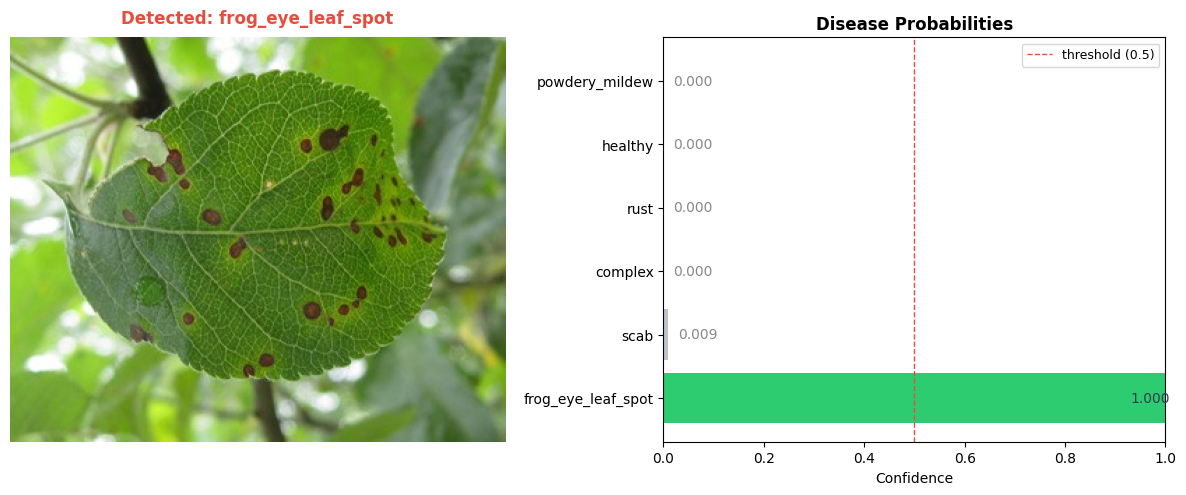

Raw scores:
  [YES] frog_eye_leaf_spot        1.0000  #############################
  [no] scab                      0.0087  
  [no] complex                   0.0001  
  [no] rust                      0.0000  
  [no] healthy                   0.0000  
  [no] powdery_mildew            0.0000  

DISEASE ANALYSIS & RECOMMENDATIONS
Querying Groq LLM...

**What's going on**
With a 100.0% confidence score, the diagnosis is clear: Frog Eye Leaf Spot is present, causing circular brown spots with purple borders on the apple leaf. This fungal disease can lead to defoliation and reduced fruit production if left untreated.

**How it spreads**
Frog Eye Leaf Spot spreads through water splashing, contaminated pruning tools, and infected debris, with warm and humid conditions exacerbating the disease. 

**Act now**
1. Remove infected leaves to prevent further spread.
2. Improve airflow around the plant to reduce humidity.

**Treatment**
Fungicides like Chlorothalonil can be applied to control the dise

In [12]:
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

img = Image.open(img_path).convert('RGB')
tensor = val_test_tf(img).unsqueeze(0).to(device)

# ── CNN inference ─────────────────────────────────────────────
with torch.no_grad():
    logits = model(tensor)
    probs  = torch.sigmoid(logits).squeeze().cpu().numpy()

preds = [(PP_LABELS[i], float(probs[i])) for i in range(6)]
preds_sorted = sorted(preds, key=lambda x: x[1], reverse=True)
detected = [p for p in preds if p[1] > 0.5]
detected_names = [d[0] for d in detected]
detected_scores = [d[1] for d in detected]

# ── Visual output ─────────────────────────────────────────────
fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 5))

ax_img.imshow(img)
ax_img.axis('off')
if detected:
    title = 'Detected: ' + ', '.join(detected_names)
    ax_img.set_title(title, fontsize=12, color='#e74c3c', fontweight='bold', pad=10)
else:
    ax_img.set_title('No disease detected — Leaf appears healthy', fontsize=11, color='#2ecc71', fontweight='bold', pad=10)

colors = ['#2ecc71' if p[1] > 0.5 else '#bdc3c7' for p in preds_sorted]
bars = ax_bar.barh([p[0] for p in preds_sorted], [p[1] for p in preds_sorted], color=colors)
ax_bar.set_xlim(0, 1)
ax_bar.axvline(x=0.5, color='#e74c3c', linestyle='--', linewidth=1, label='threshold (0.5)')
ax_bar.set_xlabel('Confidence')
ax_bar.set_title('Disease Probabilities', fontweight='bold')
ax_bar.legend(fontsize=9)

for bar, (label, prob) in zip(bars, preds_sorted):
    ax_bar.text(min(prob + 0.02, 0.93), bar.get_y() + bar.get_height()/2,
                f'{prob:.3f}', va='center', fontsize=10,
                color='#2c3e50' if prob > 0.5 else '#888')

plt.tight_layout()
plt.show()

print('Raw scores:')
for label, prob in preds_sorted:
    flag = 'YES' if prob > 0.5 else 'no'
    bar_vis = '#' * int(prob * 30)
    print(f'  [{flag}] {label:<25} {prob:.4f}  {bar_vis}')

# ── LLM explanation ───────────────────────────────────────────
print('\n' + '='*60)
print('DISEASE ANALYSIS & RECOMMENDATIONS')
print('='*60)
print('Querying Groq LLM...')

explanation = get_disease_explanation(detected_names, detected_scores)
print(f'\n{explanation}')